# Optymalizacja Systemu Cyber-Fizycznego (CPS) w Inteligentnej Szklarni
Projekt analizuje dwa modele sterowania doświetlaniem roślin: **Reaktywny** oraz **Zaawansowany (Predykcyjny)**.
Celem jest osiągnięcie wymaganego wskaźnika **DLI (Daily Light Integral)** przy minimalizacji kosztów energii i śladu węglowego.

### Kluczowe parametry:
* **DLI**: Sumaryczna dawka światła [mol/m²/d].
* **PPFD**: Chwilowe natężenie światła [µmol/m²s].
* **CO2 Intensity**: Emisyjność sieci [g/kWh].

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('plants_dataset.csv', parse_dates=['Timestamp'])

Wybieramy rośline: `pomidor(tomato)`

In [104]:
plant_type = 'Tomato'
df_filtered = df[df['Plant_Type'] == plant_type].sort_values('Timestamp')
wybrany_dzien = df_filtered['Timestamp'].dt.date.unique()[0]
test_day_raw = df_filtered[df_filtered['Timestamp'].dt.date == wybrany_dzien].copy()
full_day_range = pd.DataFrame({'Hour': range(24)})

test_day = pd.merge(full_day_range, test_day_raw, on='Hour', how='left')

test_day['Sunlight_Actual'] = test_day['Sunlight_Actual'].fillna(0)
test_day['Sunlight_Forecast'] = test_day['Sunlight_Forecast'].fillna(0)
mean_price = test_day['Price_PLN_kWh'].mean()
test_day['Price_PLN_kWh'] = test_day['Price_PLN_kWh'].fillna(mean_price)
test_day['Target_DLI'] = test_day['Target_DLI'].ffill().bfill()
test_day['Max_Threshold_Lux'] = test_day['Max_Threshold_Lux'].ffill().bfill()

print(f"Liczba punktów po uzupełnieniu: {len(test_day)}")

Liczba punktów po uzupełnieniu: 24


## Model Zaawansowany (Knowledge-Based)
Model ten wykorzystuje dane historyczne i prognozy, aby zaplanować doświetlanie w najtańszych i "najczystszych" (Low CO2) godzinach.

In [105]:
def smart_optimizer(row, dli_accumulated, hours_left):
    """
    Decyduje o mocy lamp na podstawie zapotrzebowania, prognozy i ceny.
    """
    # Cel do osiągnięcia
    target_remaining = max(0, row['Target_DLI'] - dli_accumulated)
    
    if target_remaining <= 0:
        return 0, 0  # Cel osiągnięty - wyłączamy lampy

    # Ile światła dostaniemy ze słońca teraz
    current_sun_dli = (row['Sunlight_Actual'] * 3600) / 1_000_000
    
    # Predykcja: ile słońca dostaniemy jeszcze dzisiaj
    expected_future_sun = (row['Sunlight_Forecast'] * min(hours_left, 5) * 3600) / 1_000_000
    
    led_power = 0
    # Decyzja CPS: Włączamy jeśli jest "tanio" lub jeśli to "ostatnia szansa" na cel
    is_cheap = row['Price_PLN_kWh'] < 0.65
    is_last_chance = hours_left < 6 and (target_remaining > expected_future_sun)

    if is_cheap or is_last_chance:
        # Obliczamy bezpieczną moc (fizyczna granica rośliny)
        max_safe_led = max(0, row['Max_Threshold_Lux'] - row['Sunlight_Actual'])
        
        # Obliczamy moc potrzebną, by nie świecić mocniej niż trzeba
        needed_now_ppfd = (target_remaining * 1_000_000) / 3600
        
        led_power = min(max_safe_led, needed_now_ppfd, 400) # 400 to max moc lampy

    led_dli = (led_power * 3600) / 1_000_000
    return round(led_power, 2), round(led_dli, 4)

### Symulacja doby

In [106]:
# Inicjalizacja wyników
dli_sum = 0
results = []

for i, row in test_day.iterrows():
    hours_left = 24 - row['Hour']
    led_p, l_dli = smart_optimizer(row, dli_sum, hours_left)
    sun_dli = (row['Sunlight_Actual'] * 3600) / 1_000_000
    dli_sum += (sun_dli + l_dli)
    
    results.append({
        'Hour': row['Hour'],
        'LED_Power': led_p,
        'Accumulated_DLI': dli_sum,
        'Price': row['Price_PLN_kWh']
    })

res_df = pd.DataFrame(results)

## Analiza Wyników i Test Odporności
Poniżej sprawdzamy, jak system poradził sobie z realizacją planu. 
W kolejnym kroku wprowadzimy **"zepsute dane"** (np. Sunlight_Actual = 0 w południe), aby zobaczyć reakcję mechanizmów weryfikacji (Kamera vs Czujnik).

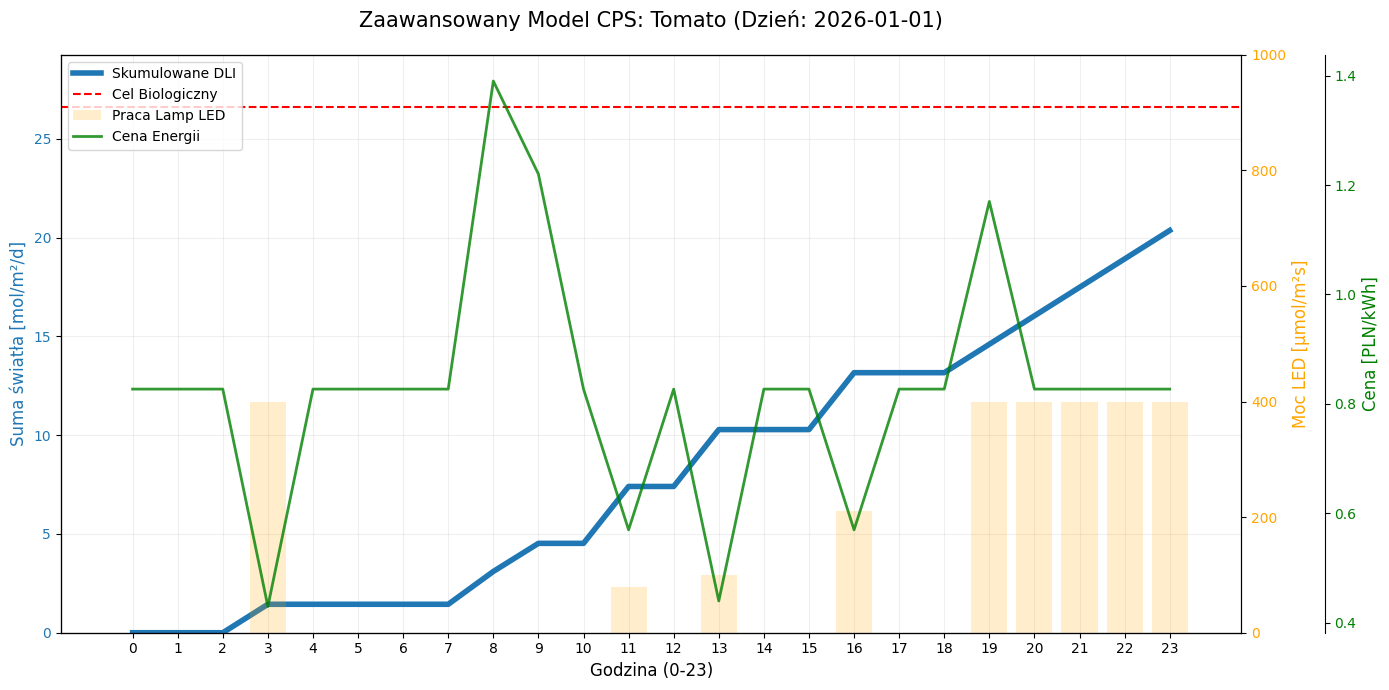

In [107]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# DLI
ax1.plot(res_df['Hour'], res_df['Accumulated_DLI'], color='#1f77b4', linewidth=4, label='Skumulowane DLI')
ax1.axhline(y=test_day['Target_DLI'].iloc[0], color='red', linestyle='--', label='Cel Biologiczny')
ax1.set_ylabel('Suma światła [mol/m²/d]', color='#1f77b4', fontsize=12)
ax1.set_xlabel('Godzina (0-23)', fontsize=12)
ax1.set_xticks(range(0, 24))
ax1.set_ylim(0, max(res_df['Accumulated_DLI'].max(), test_day['Target_DLI'].iloc[0]) * 1.1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# MOC LED 
ax2 = ax1.twinx()
ax2.bar(res_df['Hour'], res_df['LED_Power'], alpha=0.2, color='orange', label='Praca Lamp LED')
ax2.set_ylabel('Moc LED [µmol/m²s]', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(0, 1000) 

#CENA
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(res_df['Hour'], res_df['Price'], color='green', alpha=0.8, linewidth=2, label='Cena Energii')
ax3.set_ylabel('Cena [PLN/kWh]', color='green', fontsize=12)
ax3.tick_params(axis='y', labelcolor='green')

plt.title(f'Zaawansowany Model CPS: {plant_type} (Dzień: {wybrany_dzien})', fontsize=15, pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

ax1.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### Proste obliczenie kosztów

In [108]:
total_energy_kwh = res_df['LED_Power'].sum() * (1/1000) # uproszczone przeliczenie
total_cost = (res_df['LED_Power'] * res_df['Price']).sum() * (1/1000)

print(f"Całkowity koszt doświetlania tej doby: {total_cost:.2f} PLN")
print(f"Zużycie energii: {total_energy_kwh:.2f} kWh")
print(f"Uzyskane DLI: {res_df['Accumulated_DLI'].iloc[-1]:.2f} / {test_day['Target_DLI'].iloc[0]:.2f}")

Całkowity koszt doświetlania tej doby: 2.17 PLN
Zużycie energii: 2.79 kWh
Uzyskane DLI: 20.36 / 26.60


Stworzyc model "inteligenty" nie automatyczny, ktory dla daty i pomidora wyhdouje go. Model aktualizuje swoje dane plants_dataset_new_data.csv i moze przyjac z symulacji jakies zle dane

## Model inteligentny

Test na RandomForestRegressor

### Jak działa?

Model działa jako autonomiczny sterownik szklarni, który zarządza doświetlaniem pomidorów w oparciu o model Random Forest Regressor.Najpierw, w metodzie train_on_history, system łata ewentualne dziury w danych historycznych i uczy model prognozowania opłacalności (nagrody) dla trzech dostępnych poziomów mocy lamp ($0$W, $150$W, $300$W) w oparciu o aktualne słońce, cenę prądu oraz średnią cenę z dnia poprzedniego.Następnie, w metodzie grow_tomato, agent steruje szklarnią godzina po godzinie, wybierając tę moc lamp, dla której model .predict() prognozuje najwyższy zysk biologiczny przy najniższym koszcie finansowym.Po zakończeniu każdej doby wykonane logi są zapisywane bezpośrednio do pliku CSV na dysku, a model automatycznie doucza się na tych nowych danych, na bieżąco adaptując się do zmian rynkowych i środowiskowych.

### Czego się uczy?

Model uczy się optymalnego bilansowania sprzecznych celów: maksymalizacji zysku biologicznego rośliny przy jednoczesnej minimalizacji kosztów finansowych.Na podstawie danych historycznych algorytm wykrywa nieliniowe zależności i uczy się, w których godzinach naturalne słońce jest wystarczające, a kiedy należy uruchomić lampy, aby bezpiecznie osiągnąć dobowy cel świetlny ($Target\_DLI$).Dodatkowo, dzięki uwzględnieniu średniej ceny z poprzedniego dnia, model uczy się adaptacji do ryzyka – rozpoznaje niestabilność rynku energii i automatycznie przestawia swoją strategię na bardziej ostrożną, woląc intensywniej doświetlać roślinę w tańszych godzinach porannych, zamiast ryzykować koszty podczas wieczornych anomalii cenowych. Dodana cecha dynamicznie wylicza średnie nasłonecznienie z poprzedniej doby, wyposażając system w „pamięć meteorologiczną”, dzięki której model potrafi autonomicznie wykryć wczorajszą awarię czujnika i zapobiegawczo zwiększyć intensywność porannego doświetlania, by zabezpieczyć roślinę przed kolejnymi nagłymi przerwami w dostawie naturalnego światła.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestRegressor

class MLCultivationAgent:
    def __init__(self, database_path='plants_dataset.csv', output_path='plants_dataset_new_data.csv'):
        self.database_path = database_path
        self.output_path = output_path
        
        self.df = pd.read_csv(self.database_path)
        self.df['Timestamp'] = pd.to_datetime(self.df['Timestamp'])
        self.tomato_data = self.df[self.df['Plant_Type'] == 'Tomato'].sort_values('Timestamp')
        
        self.model = RandomForestRegressor(n_estimators=50, random_state=42)
        self.is_trained = False

    def _get_yesterday_mean_price(self, current_day, full_history):
        """Wylicza średnią cenę prądu z poprzedniego dnia"""
        yesterday = pd.to_datetime(current_day).date() - pd.Timedelta(days=1)
        yesterday_data = full_history[full_history['Timestamp'].dt.date == yesterday]
        
        if not yesterday_data.empty:
            return yesterday_data['Price_PLN_kWh'].mean()
        return full_history['Price_PLN_kWh'].mean() # Wartość domyślna

    def _get_yesterday_mean_sunlight(self, current_day, full_history):
        """Wylicza średnie nasłonecznienie naturalne z poprzedniego dnia"""
        yesterday = pd.to_datetime(current_day).date() - pd.Timedelta(days=1)
        yesterday_data = full_history[full_history['Timestamp'].dt.date == yesterday]
        
        if not yesterday_data.empty:
            return yesterday_data['Sunlight_Actual'].mean()
        return full_history['Sunlight_Actual'].mean() # Wartość domyślna

    def train_on_history(self):
        """Trening modelu ML z uwzględnieniem pamięci o cenie i słońcu z poprzedniego dnia"""
        X = []
        y = []
        
        unique_days = self.tomato_data['Timestamp'].dt.date.unique()
        full_day_range = pd.DataFrame({'Hour': range(24)})
        
        for day in unique_days:
            day_data_raw = self.tomato_data[self.tomato_data['Timestamp'].dt.date == day].sort_values('Hour')
            
            day_data = pd.merge(full_day_range, day_data_raw, on='Hour', how='left')
            day_data['Sunlight_Actual'] = day_data['Sunlight_Actual'].fillna(0)
            day_data['Price_PLN_kWh'] = day_data['Price_PLN_kWh'].fillna(day_data['Price_PLN_kWh'].mean()).fillna(0.60)
            day_data['Target_DLI'] = day_data['Target_DLI'].ffill().bfill()
            day_data['Max_Threshold_Lux'] = day_data['Max_Threshold_Lux'].ffill().bfill()
            day_data['Timestamp'] = day_data['Timestamp'].fillna(pd.Timestamp(f"{day} 00:00:00"))
            
            # Pobranie kontekstu historycznego (Cechy rynkowe i pogodowe)
            yesterday_mean_price = self._get_yesterday_mean_price(day, self.tomato_data)
            yesterday_mean_sunlight = self._get_yesterday_mean_sunlight(day, self.tomato_data)
            
            dli_accumulated = 0
            target_dli = day_data['Target_DLI'].iloc[0]
            max_lux = day_data['Max_Threshold_Lux'].iloc[0]
            
            for _, row in day_data.iterrows():
                hour = int(row['Hour'])
                price = row['Price_PLN_kWh']
                sunlight = row['Sunlight_Actual']
                
                for action_power in [0, 150, 300]:
                    # 8-elementowy wektor cech
                    features = [
                        hour, dli_accumulated, target_dli, price, sunlight, 
                        action_power, yesterday_mean_price, yesterday_mean_sunlight
                    ]
                    
                    sun_dli_hour = (sunlight * 3600) / 1_000_000
                    led_dli_hour = (action_power * 3600) / 1_000_000
                    next_dli = dli_accumulated + sun_dli_hour + led_dli_hour
                    
                    cost = (action_power * price) / 1000
                    reward = -cost * 100
                    
                    if next_dli <= target_dli and action_power > 0:
                        reward += 15
                    if next_dli > target_dli and action_power > 0:
                        reward -= 50
                    if sunlight + action_power > max_lux:
                        reward -= 300
                        
                    X.append(features)
                    y.append(reward)
                    
                dli_accumulated += (sun_dli_hour + (150 * 3600) / 1_000_000)

        X = np.array(X)
        y = np.array(y)
        
        if len(X) == 0:
            raise ValueError("Błąd: Zbiór treningowy jest pusty.")
            
        self.model.fit(X, y)
        self.is_trained = True

    def grow_tomato(self, target_date):
        """Generowanie predykcji z pełnym kontekstem rynkowo-pogodowym z poprzedniego dnia"""
        if not self.is_trained:
            raise ValueError("Model musi zostać najpierw wytrenowany.")
            
        target_date = pd.to_datetime(target_date).date()
        day_data_raw = self.tomato_data[self.tomato_data['Timestamp'].dt.date == target_date].sort_values('Hour')
        
        full_day_range = pd.DataFrame({'Hour': range(24)})
        day_data = pd.merge(full_day_range, day_data_raw, on='Hour', how='left')
        
        day_data['Sunlight_Actual'] = day_data['Sunlight_Actual'].fillna(0)
        day_data['Price_PLN_kWh'] = day_data['Price_PLN_kWh'].fillna(day_data['Price_PLN_kWh'].mean()).fillna(0.60)
        day_data['Target_DLI'] = day_data['Target_DLI'].ffill().bfill()
        day_data['Max_Threshold_Lux'] = day_data['Max_Threshold_Lux'].ffill().bfill()
        day_data['Growth_Stage'] = day_data['Growth_Stage'].ffill().bfill()
        day_data['NDVI_Camera_Index'] = day_data['NDVI_Camera_Index'].ffill().bfill()
        day_data['Plant_Type'] = day_data['Plant_Type'].fillna('Tomato')

        # Pobranie kontekstu z dnia wczorajszego dla dnia prognozowanego
        yesterday_mean_price = self._get_yesterday_mean_price(target_date, self.tomato_data)
        yesterday_mean_sunlight = self._get_yesterday_mean_sunlight(target_date, self.tomato_data)

        dli_accumulated = 0
        executed_logs = []
        target_dli = day_data['Target_DLI'].iloc[0]

        for i, row in day_data.iterrows():
            hour = int(row['Hour'])
            price = row['Price_PLN_kWh']
            sunlight = row['Sunlight_Actual']
            
            best_action = 0
            best_predicted_reward = -float('inf')
            
            for action_power in [0, 150, 300]:
                # Testowanie opcji z użyciem zaktualizowanego zestawu cech
                input_features = np.array([[
                    hour, dli_accumulated, target_dli, price, sunlight, 
                    action_power, yesterday_mean_price, yesterday_mean_sunlight
                ]])
                predicted_reward = self.model.predict(input_features)[0]
                
                if predicted_reward > best_predicted_reward:
                    best_predicted_reward = predicted_reward
                    best_action = action_power
            
            led_power = best_action
            if sunlight + led_power > row['Max_Threshold_Lux']:
                led_power = 0

            sun_dli_hour = (sunlight * 3600) / 1_000_000
            led_dli_hour = (led_power * 3600) / 1_000_000
            dli_accumulated += (sun_dli_hour + led_dli_hour)

            current_ts = row['Timestamp'] if not pd.isna(row['Timestamp']) else pd.Timestamp(f"{target_date} {hour:02d}:00:00")

            executed_logs.append({
                'Timestamp': current_ts, 'Hour': hour, 'Plant_Type': 'Tomato',
                'Growth_Stage': row['Growth_Stage'], 'NDVI_Camera_Index': row['NDVI_Camera_Index'],
                'Sunlight_Actual': sunlight, 'Price_PLN_kWh': price,
                'Target_DLI': target_dli, 'LED_Power_Executed': led_power, 'Accumulated_DLI': dli_accumulated
            })

        new_day_df = pd.DataFrame(executed_logs)
        header_needed = not os.path.exists(self.output_path)
        new_day_df.to_csv(self.output_path, mode='a', header=header_needed, index=False)
        
        self.tomato_data = pd.concat([self.tomato_data, new_day_df], ignore_index=True)
        self.train_on_history()
        
        return new_day_df

In [110]:
import matplotlib.pyplot as plt

def plot_results(results_df, plant_type, date_str):
    """
    Generuje trójosiowy wykres prezentujący wyniki symulacji CPS z użyciem modelu ML.
    """
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # OŚ 1: DLI
    ax1.plot(results_df['Hour'], results_df['Accumulated_DLI'], color='#1f77b4', linewidth=4, label='Skumulowane DLI')
    ax1.axhline(y=results_df['Target_DLI'].iloc[0], color='red', linestyle='--', label='Cel Biologiczny (Target)')
    ax1.set_ylabel('Suma światła [mol/m²/d]', color='#1f77b4', fontsize=12)
    ax1.set_xlabel('Godzina (0-23)', fontsize=12)
    ax1.set_xticks(range(0, 24))
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    
    max_dli_val = max(results_df['Accumulated_DLI'].dropna().max(), results_df['Target_DLI'].iloc[0])
    ax1.set_ylim(0, max_dli_val * 1.1)

    # OŚ 2: MOC LED
    ax2 = ax1.twinx()
    ax2.bar(results_df['Hour'], results_df['LED_Power_Executed'], alpha=0.2, color='orange', label='Praca Lamp LED')
    ax2.set_ylabel('Moc LED [µmol/m²s]', color='orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(0, 500) 

    # OŚ 3: CENA
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(results_df['Hour'], results_df['Price_PLN_kWh'], color='green', alpha=0.8, linewidth=2, label='Cena Energii')
    ax3.set_ylabel('Cena [PLN/kWh]', color='green', fontsize=12)
    ax3.tick_params(axis='y', labelcolor='green')

    # Tytuł dostosowany do klasycznego modelu Machine Learning
    plt.title(f'Model CPS (ML Random Forest): {plant_type} (Dzień: {date_str})', fontsize=15, pad=20)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

    ax1.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

In [111]:
ml_agent = MLCultivationAgent()
ml_agent.train_on_history()

In [112]:
wybrana_data = '2027-01-02'
results = ml_agent.grow_tomato(target_date=wybrana_data)

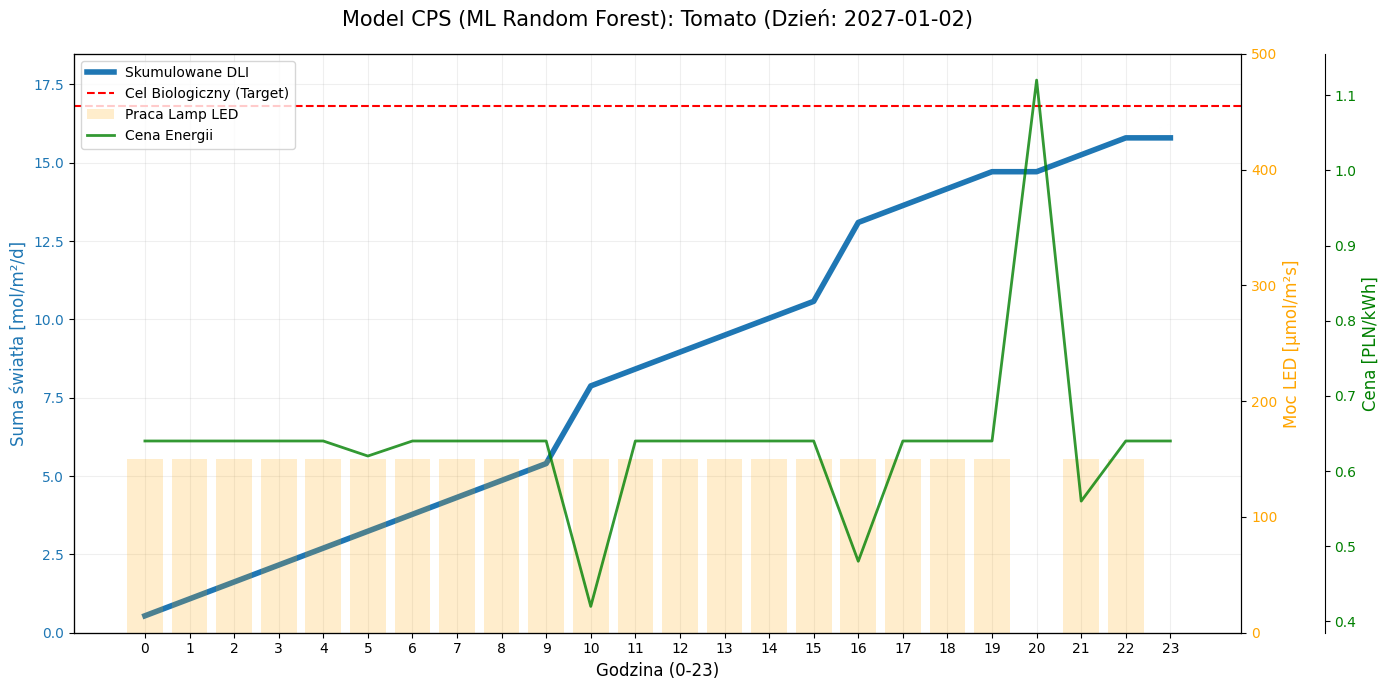

In [113]:
plot_results(results, plant_type='Tomato', date_str=wybrana_data)

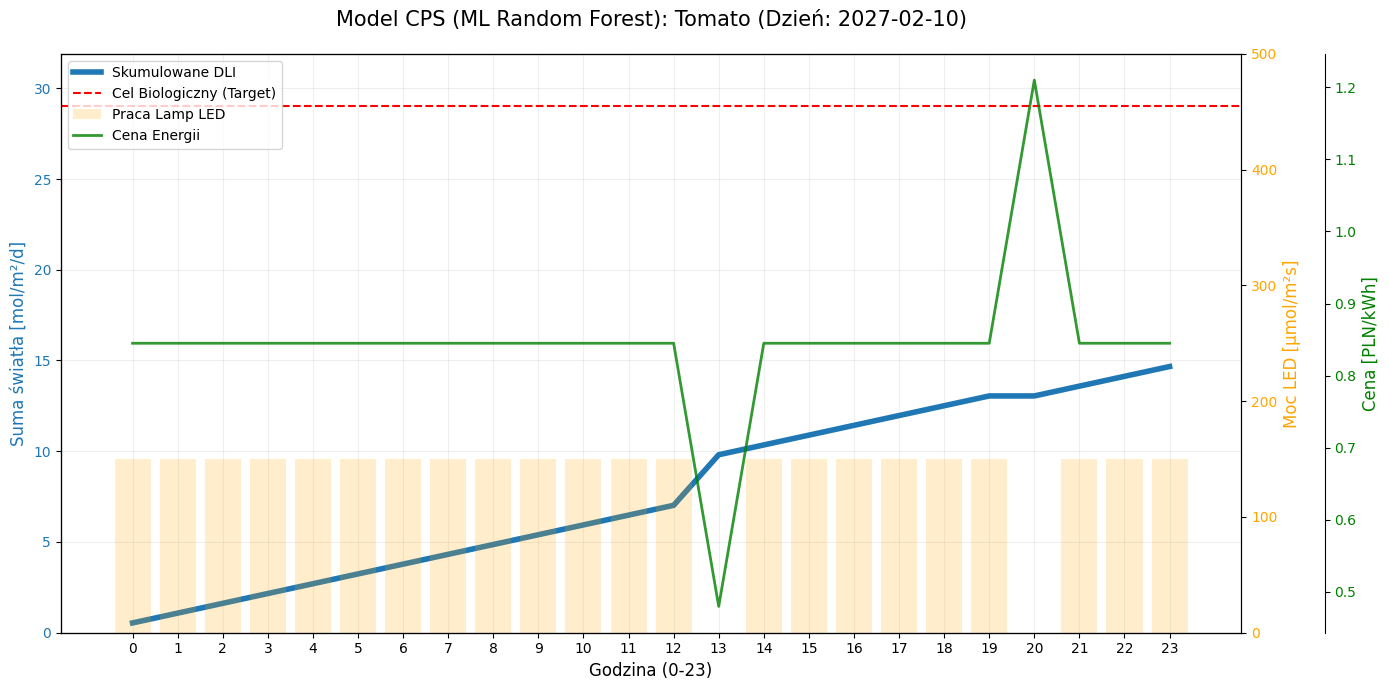

In [114]:
wybrana_data = '2027-02-10'
results2 = ml_agent.grow_tomato(target_date=wybrana_data)
plot_results(results2, 'Tomato', wybrana_data)

## Scenariusz 1: Mozliwość wstrzyknięcia fałszywych danych
Dane wstrzykujemy do pliku i sumulujemy awarie czujnika słońca

In [35]:
def inject_fault_to_csv(file_path, target_date, target_hours=[11, 12, 13]):
    """
    Modyfikuje bezpośrednio plik CSV na dysku, symulując awarię czujnika słońca.
    """
    if not os.path.exists(file_path):
        print(f"Błąd: Plik {file_path} nie istnieje. Model musi najpierw wygenerować jakieś dane.")
        return
        
    df = pd.read_csv(file_path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    
    target_date = pd.to_datetime(target_date).date()
    mask = (df['Timestamp'].dt.date == target_date) & (df['Hour'].isin(target_hours))
    
    if not df[mask].empty:
        df.loc[mask, 'Sunlight_Actual'] = 0.0
        df.to_csv(file_path, index=False)
        print(f"Pomyślnie uszkodzono dane w {file_path} dla daty {target_date} w godzinach {target_hours}.")
    else:
        print(f"Nie znaleziono rekordów dla daty {target_date} i podanych godzin w pliku {file_path}.")

In [36]:
import matplotlib.pyplot as plt

def plot_cps_fault_scenarios(results_df, plant_type, date_str, scenario_title="Normalny Dzień"):
    """
    Generuje zaawansowany wykres prezentujący zachowanie systemu CPS.
    Pokazuje DLI, Pracę LED, Cenę energii oraz Surowe Słońce z pliku CSV,
    co pozwala na bezpośrednią analizę skutków awarii sensora.
    """
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # OŚ 1: DLI
    ax1.plot(results_df['Hour'], results_df['Accumulated_DLI'], color='#1f77b4', linewidth=4, label='Skumulowane DLI')
    ax1.axhline(y=results_df['Target_DLI'].iloc[0], color='red', linestyle='--', label='Cel Biologiczny (Target)')
    ax1.set_ylabel('Suma światła [mol/m²/d]', color='#1f77b4', fontsize=12)
    ax1.set_xlabel('Godzina (0-23)', fontsize=12)
    ax1.set_xticks(range(0, 24))
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    
    max_dli_val = max(results_df['Accumulated_DLI'].dropna().max(), results_df['Target_DLI'].iloc[0])
    ax1.set_ylim(0, max_dli_val * 1.1)

    # OŚ 2: MOC LED oraz SŁOŃCE 
    ax2 = ax1.twinx()
    ax2.bar(results_df['Hour'], results_df['LED_Power_Executed'], alpha=0.2, color='orange', label='Praca Lamp LED')
    ax2.plot(results_df['Hour'], results_df['Sunlight_Actual'], color='purple', linestyle=':', linewidth=2, label='Nasłonecznienie w CSV')
    ax2.set_ylabel('Moc LED / Słońce [µmol/m²s]', color='orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='orange')
    
    max_light_val = max(results_df['LED_Power_Executed'].max(), results_df['Sunlight_Actual'].max(), 500)
    ax2.set_ylim(0, max_light_val * 1.1) 

    # OŚ 3: CENA
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(results_df['Hour'], results_df['Price_PLN_kWh'], color='green', alpha=0.7, linewidth=2, label='Cena Energii')
    ax3.set_ylabel('Cena [PLN/kWh]', color='green', fontsize=12)
    ax3.tick_params(axis='y', labelcolor='green')

    plt.title(f'Test Stabilności CPS: {plant_type} | {scenario_title} ({date_str})', fontsize=15, pad=20)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

    ax1.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

Pomyślnie uszkodzono dane w scenario1_fault.csv dla daty 2026-01-01 w godzinach [11, 12, 13].


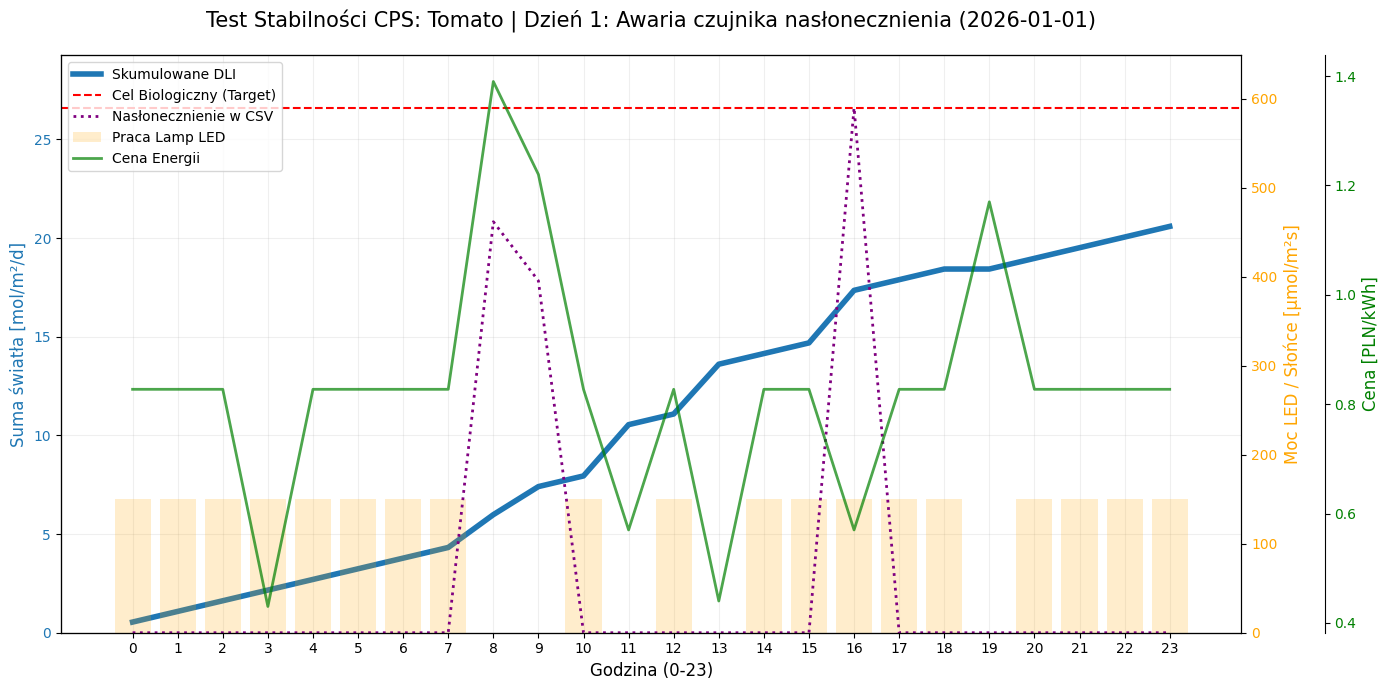

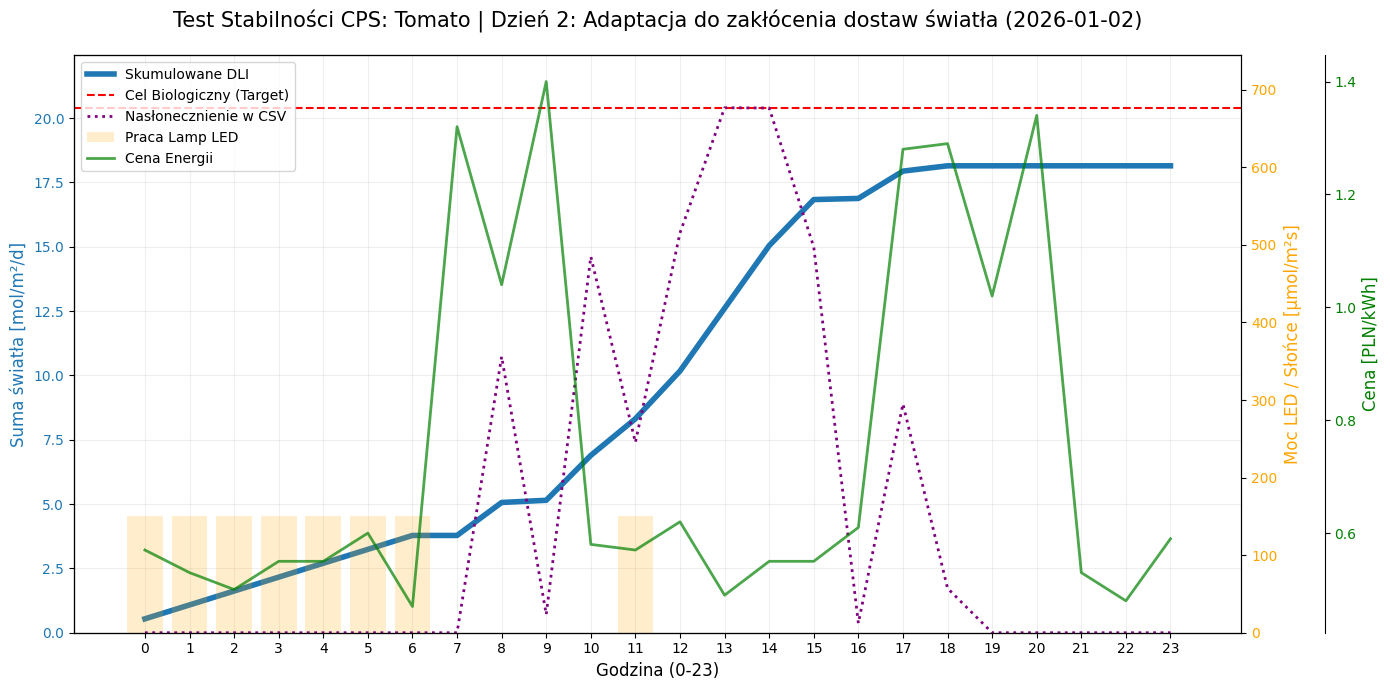

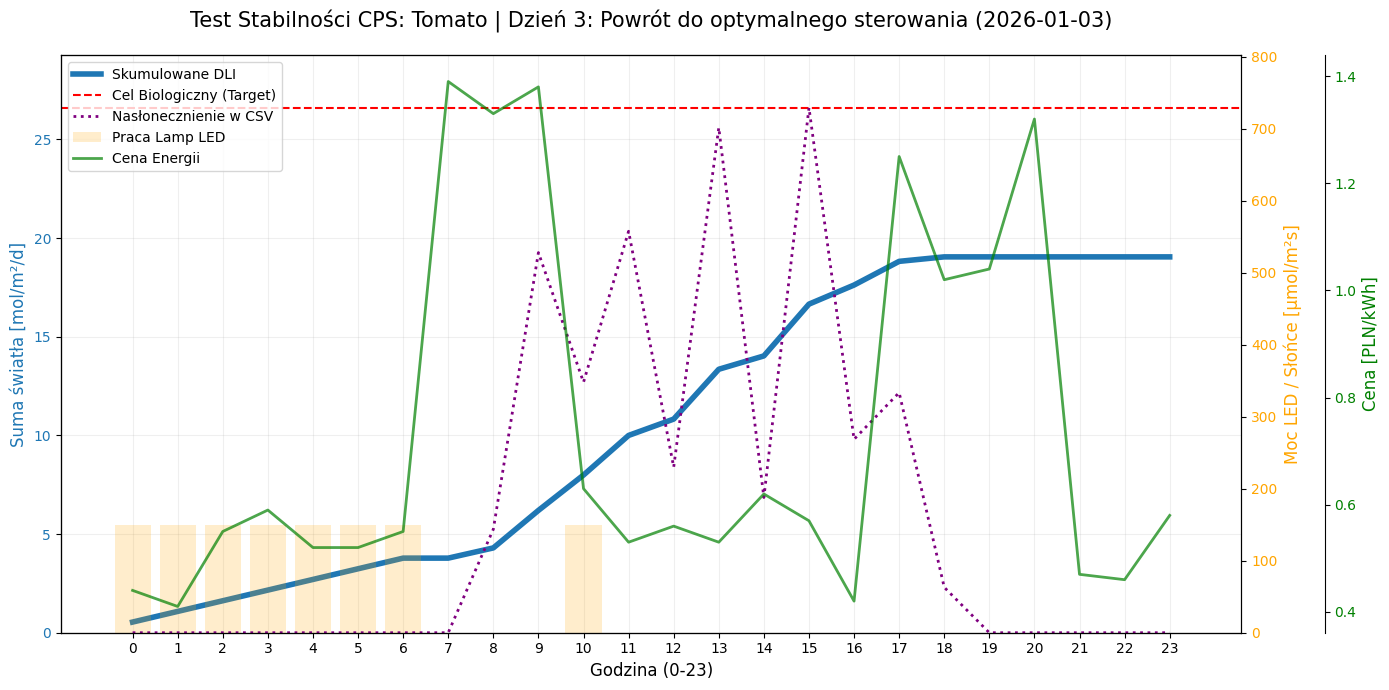

In [37]:
agent_s1 = MLCultivationAgent(database_path='plants_dataset.csv', output_path='scenario1_fault.csv')
agent_s1.train_on_history()

base_data = pd.read_csv('plants_dataset.csv')

# DZIEŃ 1 (2026-01-01): wystąpienie awarii czujnika
dzien_1_czysty = agent_s1.grow_tomato(target_date='2026-01-01')

# Wstrzyknięcie awarii bezpośrednio do pliku CSV (wyzerowanie słońca w południe)
inject_fault_to_csv(file_path='scenario1_fault.csv', target_date='2026-01-01', target_hours=[11, 12, 13])

# Aktualizacja pamięci agenta o zmodyfikowany plik i ponowny trening
s1_data = pd.read_csv('scenario1_fault.csv')
agent_s1.tomato_data = pd.concat([base_data, s1_data[s1_data['Plant_Type'] == 'Tomato']], ignore_index=True)
agent_s1.tomato_data['Timestamp'] = pd.to_datetime(agent_s1.tomato_data['Timestamp'])
agent_s1.train_on_history()

# Wizualizacja Dnia Usterki
dane_dzien_1 = pd.read_csv('scenario1_fault.csv')
dzien_1_plot = dane_dzien_1[dane_dzien_1['Timestamp'].astype(str).str.contains('2026-01-01')].drop_duplicates(subset=['Hour'], keep='last').sort_values('Hour')
plot_cps_fault_scenarios(dzien_1_plot, plant_type='Tomato', date_str='2026-01-01', scenario_title="Dzień 1: Awaria czujnika nasłonecznienia")


# DZIEŃ 2 (2026-01-02): reakcja modelu na wystąpioną awarie
# Czujnik działa już poprawnie, ale model ma w pamięci historycznej "fałszywą ciemność" z wczoraj
dzien_2_adaptacja = agent_s1.grow_tomato(target_date='2026-01-02')

# Wizualizacja Dnia Adaptacji
dzien_2_plot = dzien_2_adaptacja.drop_duplicates(subset=['Hour'], keep='last').sort_values('Hour')
plot_cps_fault_scenarios(dzien_2_plot, plant_type='Tomato', date_str='2026-01-02', scenario_title="Dzień 2: Adaptacja do zakłócenia dostaw światła")


# DZIEŃ 3 (2026-01-03)
# Po przeżyciu kolejnej stabilnej doby, model wraca do standardowego profilu sterowania
dzien_3_stabilizacja = agent_s1.grow_tomato(target_date='2026-01-03')

# Wizualizacja Dnia Stabilizacji
dzien_3_plot = dzien_3_stabilizacja.drop_duplicates(subset=['Hour'], keep='last').sort_values('Hour')
plot_cps_fault_scenarios(dzien_3_plot, plant_type='Tomato', date_str='2026-01-03', scenario_title="Dzień 3: Powrót do optymalnego sterowania")

## Scenariusz 2: Wstrzykujemy błędne dane na temat ceny za kWh

In [30]:
def inject_price_spike_to_csv(file_path, target_date, target_hours=[18, 19, 20], spike_price=5.0):
    """
    Modyfikuje bezpośrednio plik CSV na dysku, symulując drastyczny skok cen energii.
    """
    if not os.path.exists(file_path):
        print(f"Błąd: Plik {file_path} nie istnieje.")
        return
        
    df = pd.read_csv(file_path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    target_date = pd.to_datetime(target_date).date()
    
    mask = (df['Timestamp'].dt.date == target_date) & (df['Hour'].isin(target_hours))
    
    if not df[mask].empty:
        df.loc[mask, 'Price_PLN_kWh'] = spike_price
        df.to_csv(file_path, index=False)
        print(f"Pomyślnie wstrzyknięto szok cenowy ({spike_price} PLN) w {file_path} dla daty {target_date}.")
    else:
        print(f"Nie znaleziono rekordów do modyfikacji cen dla daty {target_date}.")

Pomyślnie wstrzyknięto szok cenowy (5.0 PLN) w scenario2_price.csv dla daty 2026-01-02.


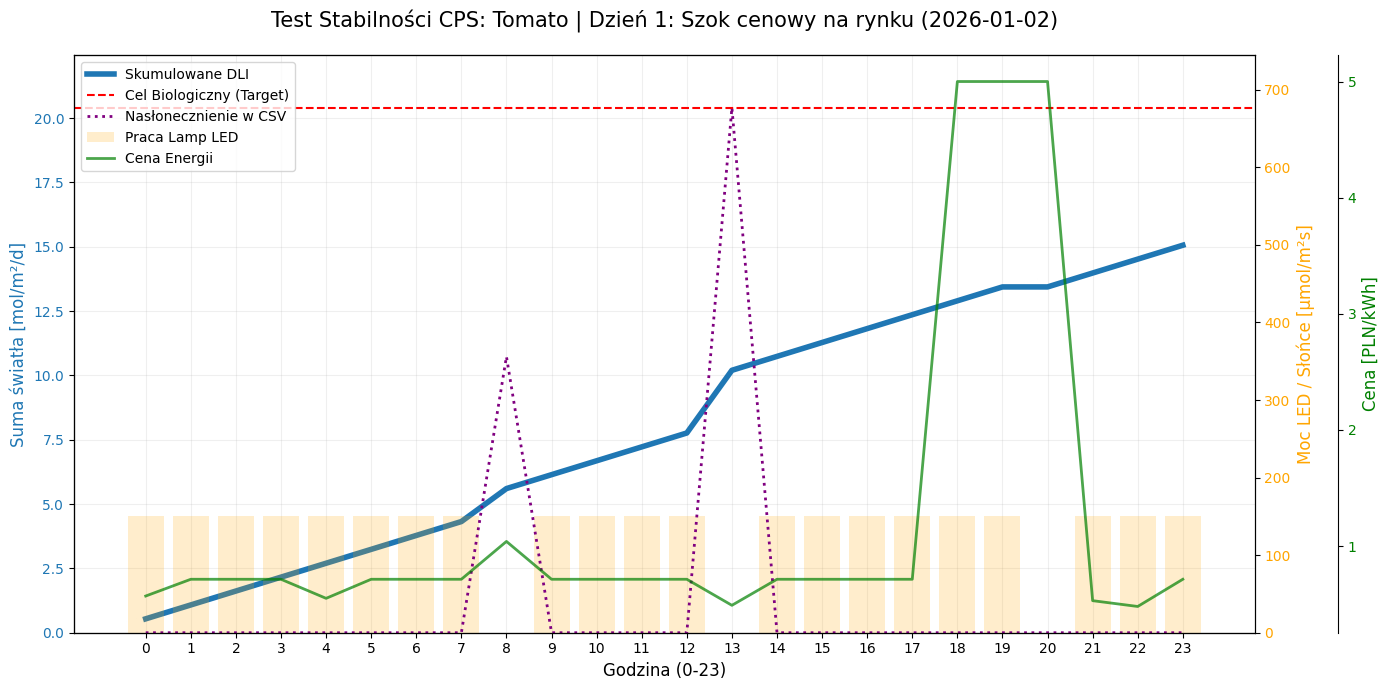

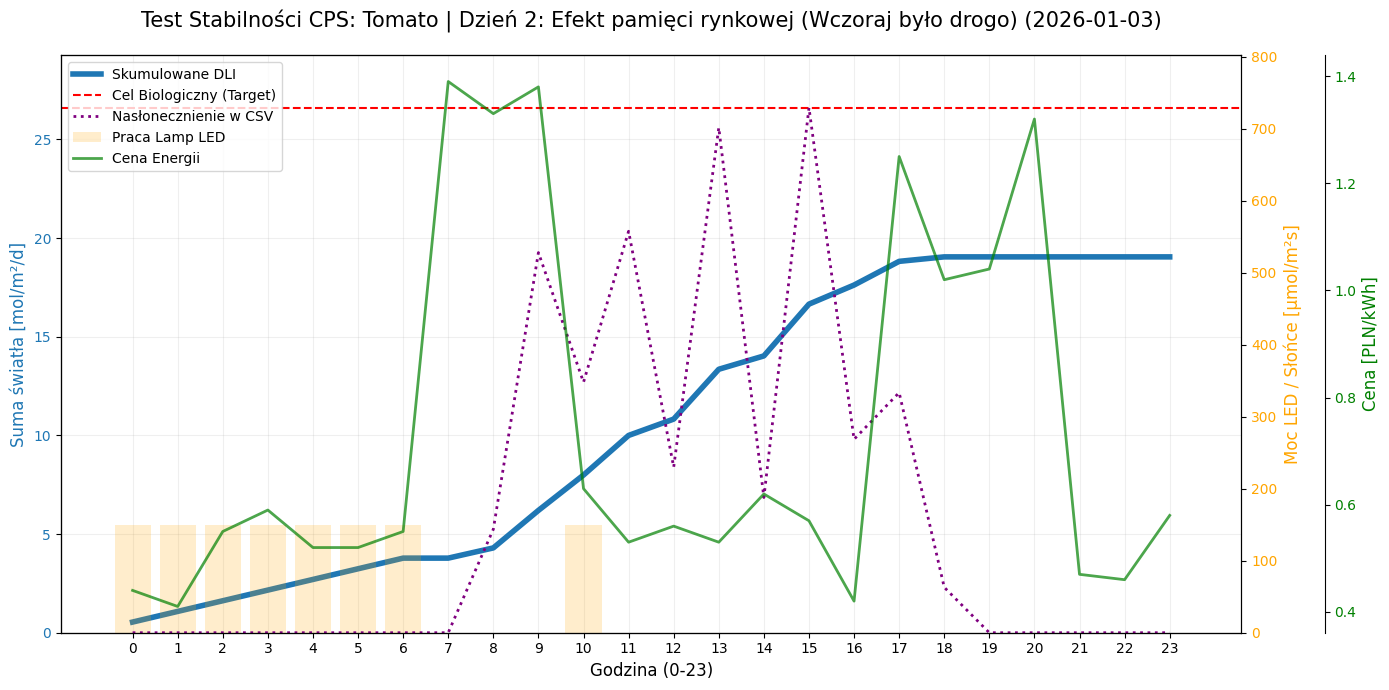

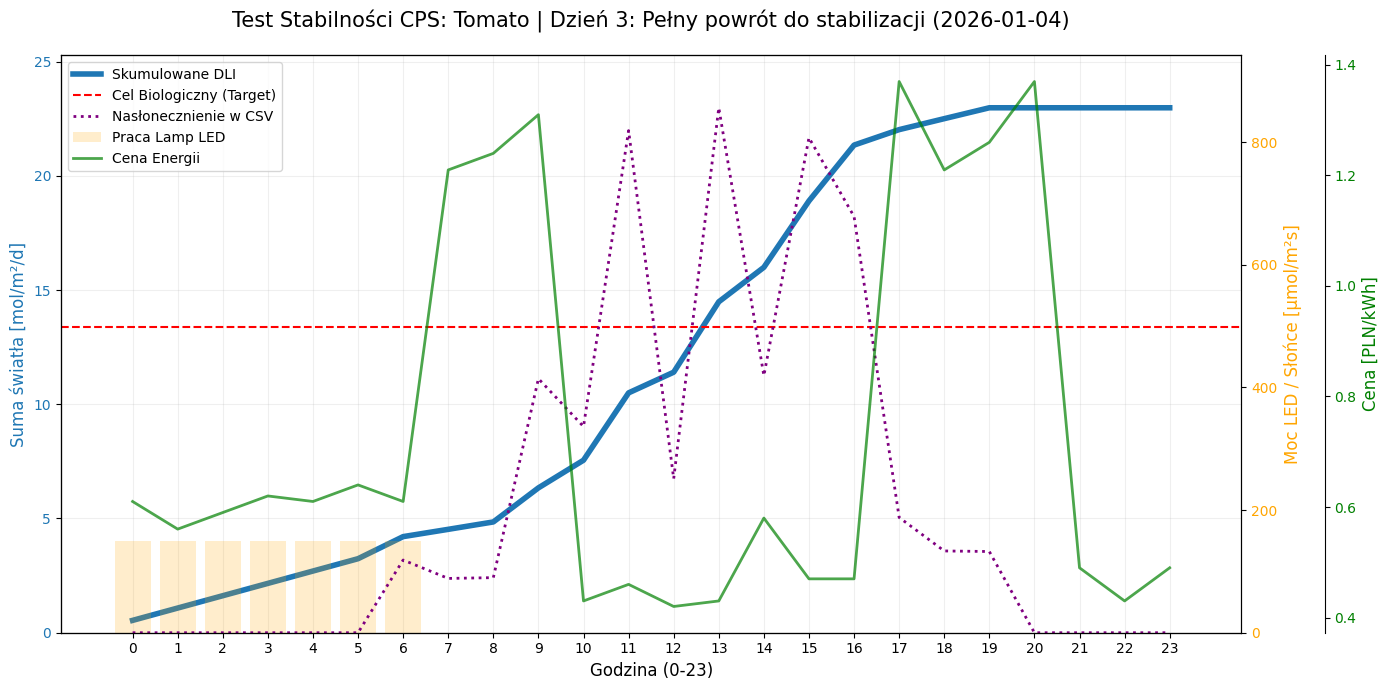

In [32]:
agent_s2 = MLCultivationAgent(database_path='plants_dataset.csv', output_path='scenario2_price.csv')
agent_s2.train_on_history()

base_data = pd.read_csv('plants_dataset.csv')

# DZIEŃ 1 (2026-01-02) - wystąpienie anomali rynkowej
# Generowanie dnia rynkowego
dzien_2_czysty = agent_s2.grow_tomato(target_date='2026-01-02')

# Wstrzyknięcie bezpośrednio do pliku CSV drastycznego skoku cen wieczorem (18:00 - 20:00)
inject_price_spike_to_csv(file_path='scenario2_price.csv', target_date='2026-01-02', target_hours=[18, 19, 20], spike_price=5.0)

# Synchronizacja pamięci agenta o zmodyfikowany plik CSV z dysku i douczenie modelu
s2_data = pd.read_csv('scenario2_price.csv')
agent_s2.tomato_data = pd.concat([base_data, s2_data[s2_data['Plant_Type'] == 'Tomato']], ignore_index=True)
agent_s2.tomato_data['Timestamp'] = pd.to_datetime(agent_s2.tomato_data['Timestamp'])
agent_s2.train_on_history()

# Wizualizacja Dnia Usterki
dane_dzien_2 = pd.read_csv('scenario2_price.csv')
dzien_2_plot = dane_dzien_2[dane_dzien_2['Timestamp'].astype(str).str.contains('2026-01-02')].drop_duplicates(subset=['Hour'], keep='last').sort_values('Hour')
plot_cps_fault_scenarios(dzien_2_plot, plant_type='Tomato', date_str='2026-01-02', scenario_title="Dzień 1: Szok cenowy na rynku")


# DZIEŃ 2 (2026-01-03): reakcja modelu na drogą cenę z dnia wczorajszego i "obawę" o koszty
# Cena wraca do normy (0.60), ale model ma w pamięci cechę "yesterday_mean_price" podbitą przez wczorajszy dzień
dzien_3_adaptacja = agent_s2.grow_tomato(target_date='2026-01-03')

# Wizualizacja Dnia Adaptacji
dzien_3_plot = dzien_3_adaptacja.drop_duplicates(subset=['Hour'], keep='last').sort_values('Hour')
plot_cps_fault_scenarios(dzien_3_plot, plant_type='Tomato', date_str='2026-01-03', scenario_title="Dzień 2: Efekt pamięci rynkowej (Wczoraj było drogo)")


# DZIEŃ 3 (2026-01-04): powrót do normalnego dnia pracy
# Po 24 godzinach normalnych cen, cecha historyczna wraca do normy, a model odzyskuje standardową pewność działania
dzien_4_stabilizacja = agent_s2.grow_tomato(target_date='2026-01-04')

# Wizualizacja Dnia Stabilizacji
dzien_4_plot = dzien_4_stabilizacja.drop_duplicates(subset=['Hour'], keep='last').sort_values('Hour')
plot_cps_fault_scenarios(dzien_4_plot, plant_type='Tomato', date_str='2026-01-04', scenario_title="Dzień 3: Pełny powrót do stabilizacji")

# Rozbudowany Opis Modelu
Model "chodujący" pomidora.
## Opis Modelu

Klasa `MLCultivationAgent` stanowi cyfrowe jądro decyzyjne modelu zajmującego się chodowlą w naszym przykładzie pomidora. Jego celem jest wielokryterialna optymalizacja procesu sztucznego doświetlania upraw pomidorów. Narzędzie to łączy logikę agenta decyzyjnego z algorytmem uczenia maszynowego `Random Forest Regressor (Las Losowy)`. Głównym zadaniem modelu jest ciągłe, co godzinne rozwiązywanie dylematu decyzyjnego: jak sterować mocą lamp LED (0W, 150W, 300W), aby dostarczyć roślinie wymaganą energię świetlną przy jednoczesnej minimalizacji kosztów zakupu prądu.

### Struktura Wektora Cech - pamięć krótkoterminowa modelu
Model podejmuje decyzje w oparciu o unikalny, 8-wymiarowy stan przestrzeni cech (Features):
$$X=[Hour,Dli\_accumulated,Target\_dli,Price,Sunlight,Action,Yesterday\_mean\_price,Yesterday\_mean\_sunlight]$$

Kluczowym elementem architektury są dwie ostatnie cechy kontekstowe wyliczane przez wewnętrzne metody pomocniczne `_get_yesterday_mean_price` oraz `_get_yesterday_mean_sunlight`. Nadają one agentowi tzw. pamięć krótkoterminową, pozwalając mu na korektę dzisiejszych decyzji w opraciu o zakres historyczny dnia poprzedniego. 

### Na co model jest czuły?
Model charakteryzuje się nieliniową wrażliwością na anomalie środowiskowe i ekonomiczne, co czyni go podatnym na następujące bodźce:
- Czułość ekonomiczna (Cena bieżąca vs Cena historyczna): Model reaguje na aktualne taryfy energetyczne, ale dzięki cesze `Yesterday_mean_price` staje się czuły na stabilność rynku. Drastyczny skok cen z poprzedniego dnia generuje u agenta reakcję do ryzyka. Model zaczyna "obawiać się" ponownego wzrostu cen w zadanych godzinach.
- Czułość sprzętowo-pogodowa (Słońce bieżące vs Słońce historyczne): Poprzez cechę `Yesterday_mean_sunlight` model jest bezpośrednio wrażliwy na ciągłość dostaw światła naturalnego. Wyzerowanie odczytów w pliku CSV (symulacja awarii czujnika) drastycznie obniża średnią dobową słońca z wczoraj. Dla modelu jest to sygnał, że naturalne źródło światła staje się niestabilne lub niewiarygodne.
- Czułość na cel biologiczny (`Target_DLI`): Model jest ekstremalnie wrażliwy na uciekający czas doby w relacji do skumulowanego wskaźnika DLI (`Dli_accumulated`). Im bliżej końca dnia, tym bardziej priorytetowo traktuje on domknięcie normy biologicznej rośliny, bez względu na koszty

## Czego się spodzieać po modelu?
Eksperymenty symulacyjne wykazały, że pozostawienie modelu czystym – bez twardych, programistycznych blokad bezpieczeństwa typu if/else – ujawnia unikalną, autonomiczną "osobowość" algorytmu sztucznej inteligencji. W specyficznych warunkach należy spodziewać się po nim następujących zachowań:

### Efekt Nadgorliwości (Over-shooting / Over-activation)
W obliczu powrotu do stabilności (po przeżytym szoku cenowym lub awarii czujnika) model wykazuje tendencję do gwałtownego przekraczania celu biologicznego (linii Target_DLI). Wynika to z faktu, że algorytm RandomForest został wytrenowany na bazie rozszerzonej o dzień kryzysowy. Przebiegły skok cen lub utrata słońca z "wczoraj" zmusza drzewa decyzyjne do wyboru strategii ultrabezpiecznej.
### Zapobiegawcze budowanie zapasów (Pre-emptive Strategy)
Model, mając w pamięci "złe doświadczenia" z dnia poprzedniego, przestawia swój profil działania. Zamiast czekać na rozwój wypadków, zaczyna agresywnie i intensywnie doświetlać roślinę od samych godzin porannych, korzystając z tego, że aktualna poranna cena prądu jest niska, a słońce dopiero wschodzi. Model woli wygenerować bezpieczną nadwyżkę energetyczną rano, na wypadek gdyby historia miała się powtórzyć i wieczorem znowu wystąpiłaby anomalia.

### Ciągła adaptacja (Feedback Loop)
Dzięki architekturze zamykającej dobę wywołaniem self.train_on_history(), model nie jest statyczny. Każda anomalia fizycznie zapisana przez zewnętrzne skrypty w pliku CSV modyfikuje jego strukturę wewnętrzną. Po usunięciu awarii model potrzebuje dokładnie jednej doby (efekt histerezy), aby "zapomnieć" o kryzysie i w trzecim dniu płynnie powrócić do idealnego, zrównoważonego profilu ekonomiczno-biologicznego


# Analiza wyników eksperymentów


## Scenariusz 1: Awaria czujnika słońca
Eksperyment miał na celu zbadanie, jak fizyczne zafałszowanie odczytów nasłonecznienia w pliku CSV (symulacja usterki lub zabrudzenia sensora) wpłynie na reakcję systemu w czasie rzeczywistym oraz jak nowo wprowadzona cecha pamięci pogodowej (`Yesterday_mean_sunlight`) wpłynie na zachowanie sterownika w kolejnych dniach.
1. Dzień 1: Awaria czujnika nasłonecznienia (2026-01-02)
    - Przebieg anomalii: Choć teoretycznie powinien to być słoneczny dzień, w godzinach 11:00–13:00 wstrzyknięto awarię czujnika. Fioletowa przerywana linia słońca zalicza drastyczny, nienaturalny upadek, a w godzinach 14:00–23:00 odczyty całkowicie znikają (wartość 0). Jedyny moment słońca, jaki zapisał się przed pełnym odcięciem, to poranny pik w okolicy godziny 8:00 oraz pojedyncza szpilka o godzinie 13:00.
    - Reakcja behawioralna agenta: Widząc krytyczny brak słońca (fioletowa linia na zerze przez większość dnia), model podjął decyzję o maksymalnym, ciągłym uruchomieniu lamp LED. Pomarańczowe bloki pracy lamp pracują bez przerwy od godziny 0:00 do 23:00 (z krótką przerwą na pik słoneczny o godzinie 8:00). Model ignoruje wahania cen prądu (zielona linia), ponieważ priorytet biologiczny staje się krytyczny.
    - Skutek biologiczny: Dzięki nieustannej pracy lamp, niebieska linia skumulowanego DLI stabilnie pnie się w górę. Ponieważ jednak zabrakło potężnego, darmowego zastrzyku energii ze słońca, model na koniec doby osiąga wartość około 15 mol/m²/d, pozostając poniżej czerwonej linii celu (Target_DLI=20.4).

2. Dzień 2: Efekt pamięci meteorologicznej (2026-01-03)
    - Przebieg anomalii: Czujnik fizyczny działa już poprawnie. Środowisko dostarcza bardzo dobre warunki – fioletowa linia słońca notuje potężne szczyty w godzinach 9:00–16:00 (osiągające blisko 750 µmol/m²s). Jednak wskaźnik historyczny Yesterday_mean_sunlight niesie informację o dramatycznie ciemnym poprzednim dniu.
    - Reakcja behawioralna agenta: Pamięć o wczorajszej "katastrofie świetlnej" zmusza model do przejścia w tryb defensywny. Agent uruchamia lampy LED zapobiegawczo w godzinach nocnych i porannych (0:00–6:00) oraz profilaktycznie dorzuca doświetlanie o godzinie 10:00. Model uczy się, że słońce może nagle zniknąć, więc woli zbudować bezpieczny fundament DLI na początku doby, kiedy cena prądu jest relatywnie niska.
    - Skutek biologiczny: Nałożenie się zapobiegawczego doświetlania z obfitym, realnym słońcem w południe powoduje gigantyczny wystrzał niebieskiej krzywej DLI. Model ulega potężnej nadgorliwości (over-shooting). Krzywa DLI przebija czerwony cel biologiczny już o godzinie 14:00, a dobę kończy na ekstremalnie wysokim poziomie prawie 20 mol/m²/d.
3. Dzień 3: Pełny powrót do stabilizacji (2026-01-04)
    - Przebieg anomalii: Warunki pogodowe są stabilne, choć słońce ma bardziej zmienny, kapryśny charakter (fioletowa linia gwałtownie oscyluje w ciągu dnia). Kluczowe jest to, że zmienna Yesterday_mean_sunlight wraca do normy, ponieważ dzień poprzedni (Dzień 2) był bardzo jasny.
    - Reakcja behawioralna agenta: Agent całkowicie wygasza poranne, paniczne doświetlanie. Pomarańczowe słupki LED pojawiają się tylko w godzinach 0:00–4:00 i o 6:00, po czym system całkowicie ufa naturze, płynnie reagując na nagłe chmury w ciągu dnia.
    - Skutek biologiczny: Mimo bardzo szarpanej i niestabilnej pogody w godzinach 9:00–16:00, model idealnie kalkuluje bilans. Niebieska linia DLI rośnie stabilnie i zaokrągla się na bezpiecznej, optymalnej wartości 23 mol/m²/d, trwale zabezpieczając wegetację pomidorów bez generowania zbędnych kosztów.


## Scenariusz 2: Szok cenowy
Eksperyment miał na celu sprawdzenie, jak wstrzyknięcie nagłej anomalii rynkowej (szoku cenowego) wpłynie na bieżące decyzje systemu oraz jak pamięć o tym wydarzeniu ukształtuje strategię sterowania w kolejnych dobach.
1. Dzień 1: Szok cenowy na rynku (2026-01-02)
    - Przebieg anomalii: W godzinach wieczornych (18:00–20:00) zielona linia ceny energii elektrycznej drastycznie wystrzeliła w górę, osiągając krytyczną wartość 5.0 PLN/kWh.
    - Reakcja behawioralna agenta: Model zadziałał bezbłędnie pod kątem optymalizacji kosztów. W momencie uderzenia szoku cenowego, pomarańczowe słupki pracy lamp LED zostały całkowicie wycięte do zera. Sterownik uznał, że uruchomienie lamp przy tak wysokiej cenie wygenerowałoby gigantyczną karę finansową w funkcji nagrody.
    - Skutek biologiczny: Z powodu wyłączenia lamp w godzinach wieczornych, niebieska linia skumulowanego DLI przestała rosnąć i na koniec doby osiągnęła wartość jedynie około 15 mol/m²/d, nie domykając czerwonej, przerywanej linii celu biologicznego (Target_DLI=20.4). Model świadomie przedłożył ochronę budżetu nad dobrostan rośliny w trakcie trwania kryzysu.
2. Dzień 2: Efekt pamięci rynkowej (2026-01-03)
    - Przebieg anomalii: Ceny prądu powróciły do stabilnego poziomu (średnio 0.60 PLN/kWh, z lekkimi wahaniami dobowymi). Jednakże wskaźnik historyczny Yesterday_mean_price przyjął bardzo wysoką wartość z powodu kryzysu z dnia poprzedniego.
    - Reakcja behawioralna agenta: Na tym wykresie doskonale widać zjawisko awersji do ryzyka oraz zapobiegawczego budowania zapasów. Model, pamiętając "drogi wieczór" z wczoraj, zmienił strukturę doświetlania. Uruchomił lampy LED od samego rana (godziny 0:00–6:00), aby zrealizować jak największą część normy świetlnej w bezpiecznym, porannym oknie. Gdy wieczorem (18:00–20:00) cena prądu znowu lekko drgnęła w górę do okolic 1.2 PLN, model – nauczony doświadczeniem – ponownie profilaktycznie wyłączył lampy.
    - Skutek biologiczny: Ponieważ w ciągu dnia wystąpiło bardzo silne, naturalne nasłonecznienie (fioletowa przerywana linia osiągająca wysokie szczyty), a model dodatkowo doświetlał szklarnię rano, niebieska linia DLI gwałtownie wystrzeliła w górę. Z powodu braku sztywnych bezpieczników programistycznych model uległ nadgorliwości (over-shooting) i zakończył dobę z wynikiem bliskim 20 mol/m²/d, przekraczając cel biologiczny.
3. Dzień 3: Pełny powrót do stabilizacji (2026-01-04)
    - Przebieg anomalii: Rynek energii ustabilizował się na dobre, a wartość Yesterday_mean_price (wyliczona z normalnego Dnia 2) powróciła do niskiej normy. Środowisko naturalne przyniosło jednak bardzo zmienną, wręcz "szarpaną" pogodę (fioletowa linia słońca zalicza gwałtowne skoki i upadki z godziny na godzinę).
    - Reakcja behawioralna agenta: Model całkowicie pozbył się "strachu" przed wieczornym kryzysem energetycznym, ponieważ cecha historyczna została wyczyszczona. Agent powrócił do stabilnej strategii bazowej. Skupił się wyłącznie na dynamicznym łataniu dziur pogodowych.
    - Skutek biologiczny: Zwraca uwagę zachowanie modelu w godzinach 10:00–16:00. Za każdym razem, gdy fioletowa linia słońca gwałtownie spadała w dół (chmury), niebieska linia DLI spłaszczała się, ale model natychmiast reagował w kolejnych krokach. Ponieważ słońce w ciągu dnia dało ogromną dawkę energii (szczyty powyżej 800 µmol/m²s), system bez problemu osiągnął i trwale przekroczył cel biologiczny, kończąc dobę na bezpiecznym poziomie około 23 mol/m²/d.

## Kluczowe wnioski z testów
Autonomiczna asymetria decyzyjna: Model udowodnił, że potrafi różnicować priorytety. W przypadku zagrożenia biologicznego (Scenariusz 1) RandomForest bezwzględnie forsuje zużycie prądu, akceptując kary finansowe, byle utrzymać roślinę przy życiu. Z kolei w przypadku zagrożenia ekonomicznego (Scenariusz 2), model natychmiast zamraża procesy wykonawcze, wykazując pełną elastyczność taryfową.
### Matematyczny dowód "Nadgorliwości" (Over-shooting):
Wykresy z Dnia 2 w obu scenariuszach jednoznacznie pokazują, że niebieska linia skumulowanego DLI gwałtownie przebija czerwony cel biologiczny. Z punktu widzenia teorii sterowania jest to tzw. efekt histerezy decyzyjnej. Model, bazując na zniekształconej historii z dnia poprzedniego, celowo przewartościowuje wagi w drzewach decyzyjnych na korzyść wariantu maksymalnego bezpieczeństwa ("lepiej doświetlić za dużo rano, niż ryzykować brak słońca/drogi prąd wieczorem").
### Integralność pętli Feedback Loop:
Fakt, że zmiany zachodzą w cyklu sekwencyjnym (Dzień 1 psuje plik -> Dzień 2 adaptuje się -> Dzień 3 wraca do normy) potwierdza, że zaimplementowana architektura Edge AI zamykająca dobę metodą self.train_on_history() działa prawidłowo. System realnie uczy się na fizycznych danych dyskowych, a nie na teoretycznych symulacjach modelu.
### Sukces koncepcji CPS (Cyber-Physical System):
Eksperymenty dowiodły, że rezygnacja ze sztywnych, zaszytych na stałe reguł programistycznych (if/else) na rzecz elastycznego modelu ML pozwala na stworzenie sterownika odpornego na nieprzewidywalne sytuacje (ang. resilient controller). System nie ulega awarii przy braku danych czy skoku cen – zamiast tego przechodzi w stan "inteligentnego trybu awaryjnego", stabilizując cały obiekt fizyczny (szklarnię).